# Estonia application: beta-binomial margin likelihood

The binomial margin likelihood treats official turnout counts as exact binomial draws;
with regional populations in the tens of thousands this makes the margins near-hard
constraints. Frame mismatch between census and turnout denominators is then forced into
the outcome coefficients, which shows up as posterior intervals that miss the known age
margins (see the age-group boxplots in the paper). The paper's Extensions section
proposes a beta-binomial margin likelihood with a learned concentration parameter as a
more forgiving alternative.

This notebook fits the beta-binomial variants of the PM and FS models (and their
three-margin PM2/FS2 counterparts) on the 2023 Estonian data and compares posterior
margins and interval widths against the binomial versions fitted in
`estonia_turnout.ipynb`.

Run headless with:
```
jupyter nbconvert --to notebook --execute --inplace betabinomial-margins.ipynb --ExecutePreprocessor.timeout=-1
```
Fits are cached under `../tmp/estonia_turnout/`, so the notebook can be interrupted and re-run.

In [1]:
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import json
import pathlib

import arviz as az
import numpy as np
import pandas as pd
import pymc
import nutpie

import salk_turnout_models as tm

print('pymc', pymc.__version__, '| nutpie', nutpie.__version__, '| arviz', az.__version__)

model_path_prefix = pathlib.Path('../tmp/estonia_turnout')

# Same sampler settings and inputs as estonia_turnout.ipynb
sample_kwargs = {'chains': 4, 'tune': 1000, 'draws': 500}
input_vars = ['age_group', 'education', 'gender', 'nationality', 'municipality']
interactions = True

pymc 6.0.1 | nutpie 0.16.10 | arviz 1.1.0


/home/velochy/salk/sandbox/salk_turnout_models/salk_turnout_models/models.py:344: SyntaxWarning: invalid escape sequence '\e'
  """


In [2]:
def run_model(config, sample_kwargs, model_path_prefix):
    model_path = pathlib.Path(model_path_prefix) / config['name']
    draws_path = model_path / 'draws.parquet'

    if draws_path.exists():
        model_df = pd.read_parquet(draws_path)
        idata_path = model_path / 'idata.nc'
        if idata_path.exists():
            idata = az.from_netcdf(idata_path)
            print(config['name'], 'cached |',
                  int(idata.sample_stats.diverging.sum().item()), 'divergences |',
                  'mean R-hat', round(tm.mean_rhat(idata), 4))
    else:
        result = tm.run_model(config, sample_kwargs=sample_kwargs, save_path=model_path)
        model_df = result['draws']
        idata = result['idata']
        print(config['name'], '|',
              int(idata.sample_stats.diverging.sum().item()), 'divergences |',
              'mean R-hat', round(tm.mean_rhat(idata), 4))

    return model_df

In [3]:
base_config = {
    'outcome_col': 'voting_intent',
    'input_cols': input_vars,
    'interactions': interactions,
    'population': '../data/census.csv',
    'margin_dist': 'betabinomial',
}

one_margin = '../data/estonia_turnout/rk2023_unit_margins.csv'
three_margins = [
    '../data/estonia_turnout/rk2023_unit_margins.csv',
    '../data/estonia_turnout/rk2023_age_group_margins.csv',
    '../data/estonia_turnout/rk2023_gender_margins.csv',
]

pm_bb_config = base_config | {
    'name': '9_pm_bb',
    'model_type': 'PM',
    'margin': one_margin,
    'survey': '../data/estonia_turnout/survey.csv',
}
fs_bb_config = base_config | {
    'name': '10_fs_bb',
    'model_type': 'FS',
    'margin': one_margin,
    'survey': '../data/estonia_turnout/survey.csv',
    'selection_survey': '../data/estonia_turnout/survey_qfree.csv',
}
pm2_bb_config = base_config | {
    'name': '11_pm2_bb',
    'model_type': 'PM',
    'margin': three_margins,
    'survey': '../data/estonia_turnout/survey_qfree.csv',
}
fs2_bb_config = base_config | {
    'name': '12_fs2_bb',
    'model_type': 'FS',
    'margin': three_margins,
    'survey': '../data/estonia_turnout/survey_qfree.csv',
}

pm_bb_df = run_model(pm_bb_config, sample_kwargs, model_path_prefix)
fs_bb_df = run_model(fs_bb_config, sample_kwargs, model_path_prefix)
pm2_bb_df = run_model(pm2_bb_config, sample_kwargs, model_path_prefix)
fs2_bb_df = run_model(fs2_bb_config, sample_kwargs, model_path_prefix)

9_pm_bb


NUTS[nutpie]: [outcome_intercept, outcome_age_group_tau, outcome_age_group_effect, outcome_education_tau, outcome_education_effect, outcome_gender_tau, outcome_gender_effect, outcome_nationality_tau, outcome_nationality_effect, outcome_municipality_tau, outcome_municipality_effect, outcome_age_group_education_tau, outcome_age_group_education_effect, outcome_age_group_gender_tau, outcome_age_group_gender_effect, outcome_age_group_nationality_tau, outcome_age_group_nationality_effect, outcome_age_group_municipality_tau, outcome_age_group_municipality_effect, outcome_education_gender_tau, outcome_education_gender_effect, outcome_education_nationality_tau, outcome_education_nationality_effect, outcome_education_municipality_tau, outcome_education_municipality_effect, outcome_gender_nationality_tau, outcome_gender_nationality_effect, outcome_gender_municipality_tau, outcome_gender_municipality_effect, outcome_nationality_municipality_tau, outcome_nationality_municipality_effect, margin_0_ob

Output()

Sampling: [poststratified_outcome]


Output()

9_pm_bb | 92 divergences | mean R-hat 1.0101
10_fs_bb


NUTS[nutpie]: [outcome_intercept, outcome_age_group_tau, outcome_age_group_effect, outcome_education_tau, outcome_education_effect, outcome_gender_tau, outcome_gender_effect, outcome_nationality_tau, outcome_nationality_effect, outcome_municipality_tau, outcome_municipality_effect, outcome_age_group_education_tau, outcome_age_group_education_effect, outcome_age_group_gender_tau, outcome_age_group_gender_effect, outcome_age_group_nationality_tau, outcome_age_group_nationality_effect, outcome_age_group_municipality_tau, outcome_age_group_municipality_effect, outcome_education_gender_tau, outcome_education_gender_effect, outcome_education_nationality_tau, outcome_education_nationality_effect, outcome_education_municipality_tau, outcome_education_municipality_effect, outcome_gender_nationality_tau, outcome_gender_nationality_effect, outcome_gender_municipality_tau, outcome_gender_municipality_effect, outcome_nationality_municipality_tau, outcome_nationality_municipality_effect, margin_0_ob

Output()

## Learned beta-binomial concentration

A large concentration means the beta-binomial degenerates towards the binomial
(margins treated as near-exact); a small one means the model absorbs frame mismatch
as margin-level overdispersion.

In [4]:
for name in ['9_pm_bb', '10_fs_bb', '11_pm2_bb', '12_fs2_bb']:
    idata_path = model_path_prefix / name / 'idata.nc'
    if not idata_path.exists():
        continue
    idata = az.from_netcdf(idata_path)
    scales = {v: float(idata.posterior[v].median()) for v in idata.posterior.data_vars
              if v.endswith('obs_scale')}
    print(name, 'posterior median concentration:', {k: round(v, 1) for k, v in scales.items()})

9_pm_bb posterior median concentration: {'margin_0_obs_scale': 488.7}
10_fs_bb posterior median concentration: {'margin_0_obs_scale': 428.9}
11_pm2_bb posterior median concentration: {'margin_0_obs_scale': 409.4, 'margin_1_obs_scale': 473.9, 'margin_2_obs_scale': 1155.9}
12_fs2_bb posterior median concentration: {'margin_0_obs_scale': 672.0, 'margin_1_obs_scale': 593.2, 'margin_2_obs_scale': 832.1}


## Posterior margins vs known values

Compare age-group and gender margin posteriors of the binomial models
(`4_pm`, `5_fs`, `6_pm2`, `7_fs2` from `estonia_turnout.ipynb`) with the
beta-binomial variants, against the official turnout margins.

In [5]:
MODELS = {
    '4_pm': 'PM', '9_pm_bb': 'PM (bb)',
    '5_fs': 'FS', '10_fs_bb': 'FS (bb)',
    '6_pm2': 'PM3', '11_pm2_bb': 'PM3 (bb)',
    '7_fs2': 'FS3', '12_fs2_bb': 'FS3 (bb)',
}


def margin_posterior(model_dir, cols):
    draws = pd.read_parquet(pathlib.Path(model_dir) / 'draws.parquet')
    g = draws.groupby(['chain', 'draw'] + cols, observed=False)[['N', 'N_census']].sum().reset_index()
    g['turnout'] = g['N'] / g['N_census']
    return g


def known_margin(path, col):
    df = pd.read_csv(path)
    piv = df.pivot_table(index=col, columns='voting_intent', values='N', aggfunc='sum')
    return (piv['Yes'] / (piv['Yes'] + piv['No'])).rename('true_turnout')


known = {
    'age_group': known_margin('../data/estonia_turnout/rk2023_age_group_margins.csv', 'age_group'),
    'gender': known_margin('../data/estonia_turnout/rk2023_gender_margins.csv', 'gender'),
}

summary_rows = []
posteriors = {}
for model_dir, label in MODELS.items():
    path = model_path_prefix / model_dir
    if not (path / 'draws.parquet').exists():
        print('skipping (not fitted):', model_dir)
        continue
    for col, truth in known.items():
        post = margin_posterior(path, [col])
        posteriors[(label, col)] = post
        q = post.groupby(col, observed=True)['turnout'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()
        q.columns = ['q05', 'q25', 'q50', 'q75', 'q95']
        q = q.join(truth, how='inner')
        summary_rows.append(pd.DataFrame({
            'model': label,
            'margin': col,
            'mae': [np.abs(q.q50 - q.true_turnout).mean()],
            'cover50': [((q.true_turnout >= q.q25) & (q.true_turnout <= q.q75)).mean()],
            'cover90': [((q.true_turnout >= q.q05) & (q.true_turnout <= q.q95)).mean()],
            'width90': [(q.q95 - q.q05).mean()],
        }))

summary_df = pd.concat(summary_rows, ignore_index=True)
print(summary_df.round(3).to_string(index=False))

   model    margin   mae  cover50  cover90  width90
      PM age_group 0.066    0.143    0.286    0.099
      PM    gender 0.017    0.000    1.000    0.051
 PM (bb) age_group 0.063    0.143    0.429    0.110
 PM (bb)    gender 0.009    1.000    1.000    0.060
      FS age_group 0.053    0.143    0.571    0.107
      FS    gender 0.009    0.000    1.000    0.047
 FS (bb) age_group 0.051    0.286    0.571    0.118
 FS (bb)    gender 0.011    0.500    1.000    0.058
     PM3 age_group 0.000    1.000    1.000    0.006
     PM3    gender 0.000    1.000    1.000    0.003
PM3 (bb) age_group 0.012    0.429    1.000    0.085
PM3 (bb)    gender 0.002    1.000    1.000    0.032
     FS3 age_group 0.000    1.000    1.000    0.006
     FS3    gender 0.000    1.000    1.000    0.003
FS3 (bb) age_group 0.009    0.571    1.000    0.055
FS3 (bb)    gender 0.003    1.000    1.000    0.028


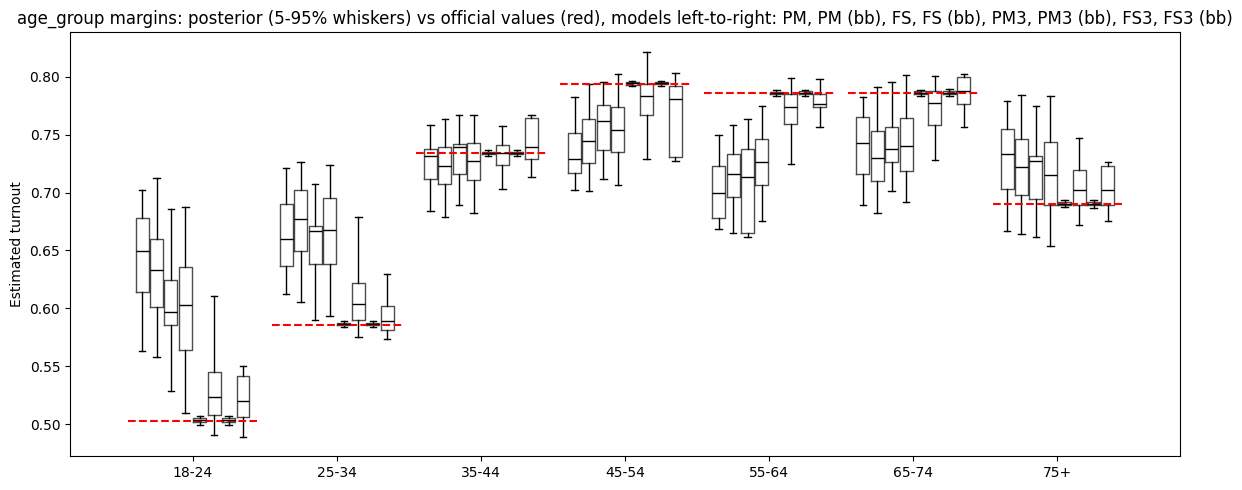

In [6]:
import matplotlib.pyplot as plt

col = 'age_group'
labels = [lab for (lab, c) in posteriors if c == col]
cats = list(known[col].index)

fig, ax = plt.subplots(figsize=(12, 5))
n_models = len(labels)
width = 0.8 / max(n_models, 1)
for j, lab in enumerate(labels):
    post = posteriors[(lab, col)]
    data = [post.loc[post[col] == cat, 'turnout'].values for cat in cats]
    positions = [i + (j - (n_models - 1) / 2) * width for i in range(len(cats))]
    ax.boxplot(data, positions=positions, widths=width * 0.9,
               whis=(5, 95), showfliers=False,
               boxprops={'alpha': 0.7}, medianprops={'color': 'black'})
    for pos, d in zip(positions, data):
        ax.text(pos, np.median(d), '', fontsize=1)  # keep positions referenced
for i, cat in enumerate(cats):
    ax.hlines(known[col][cat], i - 0.45, i + 0.45, colors='red', linestyles='dashed')
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats)
ax.set_ylabel('Estimated turnout')
ax.set_title(f'{col} margins: posterior (5-95% whiskers) vs official values (red), '
             f'models left-to-right: {", ".join(labels)}')
plt.tight_layout()
plt.show()